In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END,add_messages
from typing import TypedDict,List,Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage,HumanMessage,RemoveMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages.utils import count_tokens_approximately,trim_messages


In [2]:
load_dotenv()

model = ChatOpenAI()

In [3]:
class MessageState(TypedDict):

    messages : Annotated[List[BaseMessage],add_messages]

In [4]:
def chat_node(state:MessageState)->dict:

    messages = state['messages']

    response = model.invoke(messages)
    print('Current token is approx :',count_tokens_approximately(messages=messages))
    return {'messages':[response]}

In [22]:
def clean_up(state:MessageState)->dict:

    messages = state['messages']

    if len(messages)>10:
        to_remove = messages[:6]
        return {'messages':[RemoveMessage(id=[m.id for m in to_remove])]}
    
    return {}
    

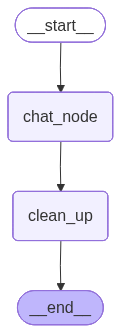

In [23]:
graph = StateGraph(MessageState)

graph.add_node('chat_node',chat_node)
graph.add_node('clean_up',clean_up)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node','clean_up')
graph.add_edge('clean_up',END)

checkpointer = InMemorySaver()

chatbot = graph.compile(checkpointer=checkpointer)

chatbot

In [7]:
config = {'configurable':{'thread_id':'thread-1'}}

chatbot.invoke({'messages':[HumanMessage(content='My name is Khan')]},config=config)
chatbot.invoke({'messages':[HumanMessage(content='Tell me about LangGraph')]},config=config)
chatbot.invoke({'messages':[HumanMessage(content='Now explain checkpointers')]},config=config)

Current token is approx : 8
Current token is approx : 36
Current token is approx : 163


{'messages': [HumanMessage(content='My name is Khan', additional_kwargs={}, response_metadata={}, id='eba520bc-2163-482c-bbbc-4649bb88a561'),
  AIMessage(content='Nice to meet you, Khan! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 11, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DEb9l4pMcPkyoCp7DyRhDJJhCvuPa', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ca997-5a36-78a1-bffd-fefc96a78eb6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 14, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outpu

In [24]:
chatbot.invoke({'messages':[HumanMessage(content='What is Gen AI')]},config=config)

Current token is approx : 8


{'messages': [HumanMessage(content='What is Gen AI', additional_kwargs={}, response_metadata={}, id='b65dc468-db9b-485b-bdb3-2eaa060cdc00'),
  AIMessage(content='Gen AI stands for Generation Artificial Intelligence, which refers to the next generation of AI systems that have the ability to learn from their own experiences and data, rather than relying solely on pre-programmed algorithms. Gen AI is designed to be more advanced and adaptive, capable of understanding complex concepts, reasoning, and decision-making. This next wave of AI is expected to be able to perform a wide range of tasks with greater efficiency and accuracy, from analysis to problem-solving to creative tasks.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 11, 'total_tokens': 106, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_t

In [25]:
snap = chatbot.get_state(config)
for message in snap.values['messages']:
    print(f"-{message.__class__.__name__} : {message.content}")

-HumanMessage : What is Gen AI
-AIMessage : Gen AI stands for Generation Artificial Intelligence, which refers to the next generation of AI systems that have the ability to learn from their own experiences and data, rather than relying solely on pre-programmed algorithms. Gen AI is designed to be more advanced and adaptive, capable of understanding complex concepts, reasoning, and decision-making. This next wave of AI is expected to be able to perform a wide range of tasks with greater efficiency and accuracy, from analysis to problem-solving to creative tasks.


In [26]:
print(len(snap.values['messages']))

2
